# 03. Models Training, Evaluation, Calibration:

### AAI-590 Group 9: Tyler Clinscales, Edwin Merchan, Geoffrey Fadera
---
### Section 1. Pretraining Pipeline:
    1. Baseline modeling on using in-location Train-Val 1st year dataset (see 02_eda_spatial_temporal_split.ipynb)
        • Model0 ScratchResNet (there is a separate notebook dedicated for ScratchResNet. the ScratchResNet below is for pipeline integration task only)
        • Model1 ResNet18  (transfer learning, used most recent ResNet18 default pretrained weights, simple Linear)  
        • Model2 ResNet18 w/ Temporal Vector

    2. Multi-Class Classification Performance Evaluation on in-loc test set, and out-loc test set.

    3. TvA Calibration Evaluation on in-loc test set and out loc test set. (Our chosen confidence calibrator TvA Histogram Binning does not change the predicted label - that is why we are able to perform TvA Calibration analysis after classification evaluation)

Minimal hyper parameter tuning was executed on both Models 1 and 2, so we can focus work on our production pipeline. <br>
Our ScratcResNet notebook demonstrates further optimization techniques (see specific ScratchResNet notebook)

---

In [1]:
# Step 1. Setup and Imports
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

import subprocess

def get_repo_root():
    return subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode('utf-8').strip()
repo_root = get_repo_root()
print(repo_root)

src_path = os.path.join(repo_root, 'src')
# Add src_path to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, repo_root)
    sys.path.insert(0, src_path)
#sys.path.append(str(repo_root))

# Set random seeds for reproducibility
RANDOM_SEED = 42


import logging
# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(funcName)s() - %(message)s"
)
logger = logging.getLogger(__name__)

def set_seed(seed: int):
    # Python built‐ins
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch CPU & CUDA
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # PyTorch MPS (Apple GPU)
    if torch.backends.mps.is_available():
        try:
            # New in PyTorch 2+: seeds MPS generator
            torch.mps.manual_seed(seed)
        except AttributeError:
            # Fallback pre–PyTorch 2.0: no direct MPS seeding, CPU generator only
            torch.manual_seed(seed)

    # Enforce deterministic algorithms where possible
    torch.use_deterministic_algorithms(True)
    # For CUDA backends only:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# Example usage
set_seed(RANDOM_SEED)
print(f"Project root: {repo_root}")


/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan
Project root: /Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan


In [2]:
# Step 2. Import Required custom classes

import importlib
import wildscan_ml_system
import custom_models
import trainer


importlib.reload(wildscan_ml_system)
importlib.reload(custom_models)
importlib.reload(trainer)

from custom_models import AnimalTemporalClassifier, AnimalClassifier, ScratchResNet
from trainer import WildScanTrainer as Trainer
from wildscan_ml_system import PretrainingPipeline, SystemConfig  



In [3]:
# Step 3: Create SystemConfig for PretrainingPipeline Only
def create_notebook_config():
    
    """Create configuration optimized for notebook pretraining"""
    def get_device():
        if torch.cuda.is_available():
            return "cuda"
        elif torch.backends.mps.is_available():
            return "mps"
        else:
            return "cpu"

    config = SystemConfig(
        # Project settings
        project_name="notebook_pretraining",
        experiment_name="pretraining_experiment",

        device = get_device(),
        # Data paths
        train_data_path="./data_split/train-meta.csv", #benchmark eccv18 1st year
        val_data_path="./data_split/val-meta.csv", #benchmark eccv18 1st year (calibration data)
        test_data_path="./data_split/test-meta.csv",#benchmark eccv18 1st year (in distribution test set)
        ood_data_path="./data_split/year1/val-meta.csv", # out of distribution data for year 1
        

        # Preprocessed images path
        preprocessed_images_path= "../dataset/cct_resized/",

        # label mapping path
        label2idx_path = "./data_split/label_mapping.json",

        # models to use
        models_to_use = [0, 1, 2],
        
        # Training settings (notebook-friendly)
        batch_size=32,
        learning_rate=1e-4,
        weight_decay=0,
        patience = 0,
        epochs=10,  # Reduced for notebook

        # criterion
        criterion=nn.CrossEntropyLoss(),
        
        # Pipeline settings - ONLY PRETRAINING
        enable_pretraining_pipeline=True,
        enable_production_pipeline=False,  # Not needed

        # model training output dir
        training_output_dir="./pretrained_models",
        
        # Logging
        output_dir="./notebook_outputs",
        log_level="INFO",
        #console_logging=False,
        #include_full_file_paths=False  # Cleaner for notebook
        
    )
    
    
    
    return config

# Create configuration
config = create_notebook_config()
print("📝 Configuration created for notebook pretraining")
print(f"   - Device: {config.device}")
print(f"   - Output: {config.output_dir}")
print(f"   - Epochs: {config.epochs}")

📝 Configuration created for notebook pretraining
   - Device: mps
   - Output: ./notebook_outputs
   - Epochs: 10


In [4]:
# Step 4: Initialize PretrainingPipeline Directly
# Create the pipeline instance WITHOUT MasterMLSystem
pretraining_pipeline = []
pretraining_pipeline = PretrainingPipeline(config)

print("🔬 PretrainingPipeline initialized successfully!")
#print(f"   - Default optimizer: {pretraining_pipeline.default_trainer_config.optimizer_class.__name__}")
#print(f"   - Default epochs: {pretraining_pipeline.default_trainer_config.epochs}")

🔬 PretrainingPipeline initialized successfully!


2025-08-13 22:18:08,510 - INFO - wildscan_ml_system.py:544 - run_pipeline() - 🔬 Starting Pretraining Pipeline...
2025-08-13 22:18:08,511 - INFO - wildscan_ml_system.py:288 - setup_datasets() - Setting up datasets for pretraining...
2025-08-13 22:18:08,548 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (9088, 16)
2025-08-13 22:18:08,548 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 22:18:08,549 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 9088 samples.
2025-08-13 22:18:08,555 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (1463, 16)
2025-08-13 22:18:08,556 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-13 22:18:08,556 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 1463 samples.
2025-08-13 22:18:08,577 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (7188, 16)
2025-08-13 22:18:08,577 - IN

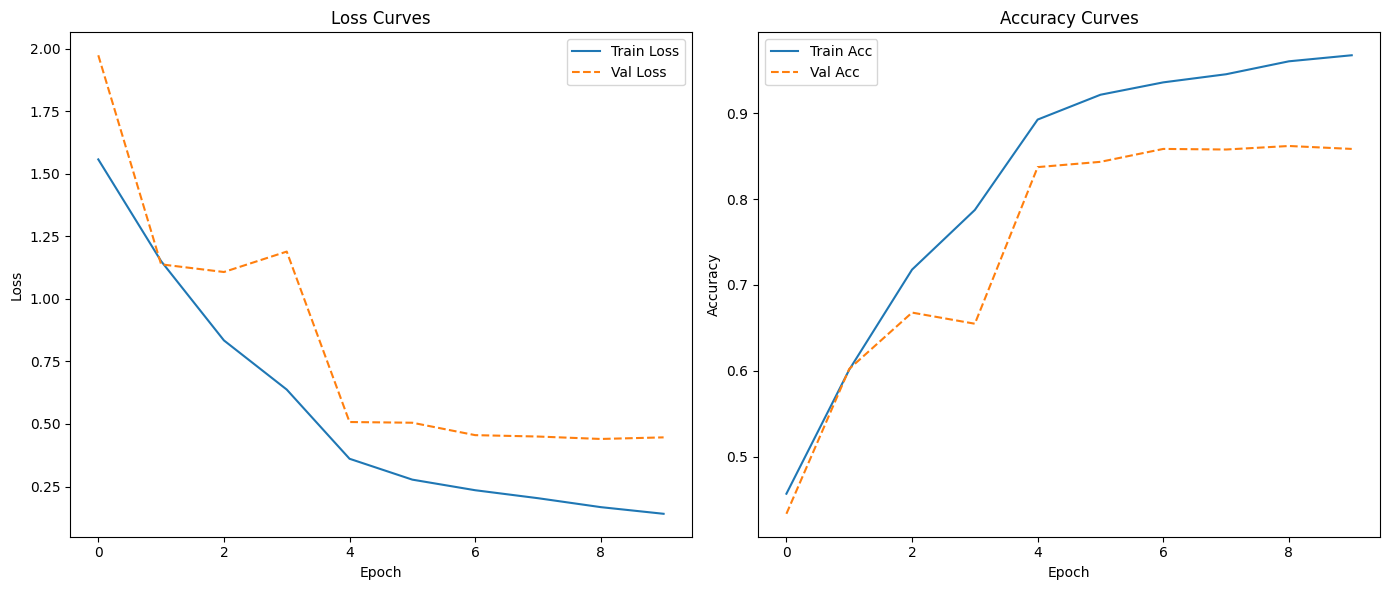

2025-08-13 22:28:43,122 - INFO - wildscan_ml_system.py:402 - train_models() - Model No 0 : ScratchResNet loaded with best weights.
2025-08-13 22:28:43,127 - INFO - wildscan_ml_system.py:364 - train_models() - Training Model No 1 : AnimalClassifier_ResNet18...
2025-08-13 22:28:43,200 - INFO - trainer.py:69 - __init__() - Using loss function: CrossEntropyLoss
2025-08-13 22:28:43,201 - INFO - trainer.py:74 - __init__() - Using learning rate scheduler: ReduceLROnPlateau with params: {'factor': 0.1, 'optimizer': Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
), 'default_min_lr': 0, 'min_lrs': [0], 'patience': 0, 'cooldown': 0, 'cooldown_counter': 0, 'mode': 'min', 'threshold': 0.0001, 'threshold_mode': 'rel', 'eps': 1e-08, 'last_epoch': 0, '_last_lr': [0.0001], 'mode_worse': inf, 'best':

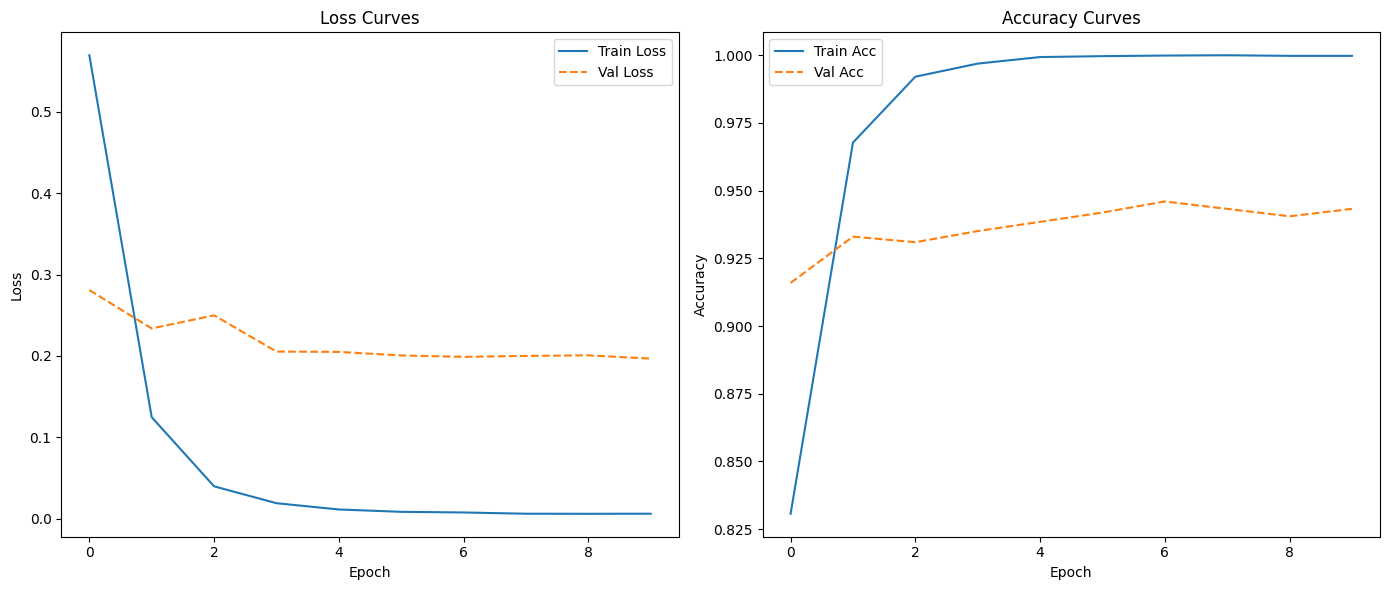

2025-08-13 22:39:10,194 - INFO - wildscan_ml_system.py:402 - train_models() - Model No 1 : AnimalClassifier_ResNet18 loaded with best weights.
2025-08-13 22:39:10,197 - INFO - wildscan_ml_system.py:364 - train_models() - Training Model No 2 : AnimalTemporalClassifier_ResNet18...
2025-08-13 22:39:10,309 - INFO - trainer.py:69 - __init__() - Using loss function: CrossEntropyLoss
2025-08-13 22:39:10,310 - INFO - trainer.py:74 - __init__() - Using learning rate scheduler: ReduceLROnPlateau with params: {'factor': 0.1, 'optimizer': Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
), 'default_min_lr': 0, 'min_lrs': [0], 'patience': 0, 'cooldown': 0, 'cooldown_counter': 0, 'mode': 'min', 'threshold': 0.0001, 'threshold_mode': 'rel', 'eps': 1e-08, 'last_epoch': 0, '_last_lr': [0.0001], 'mode_

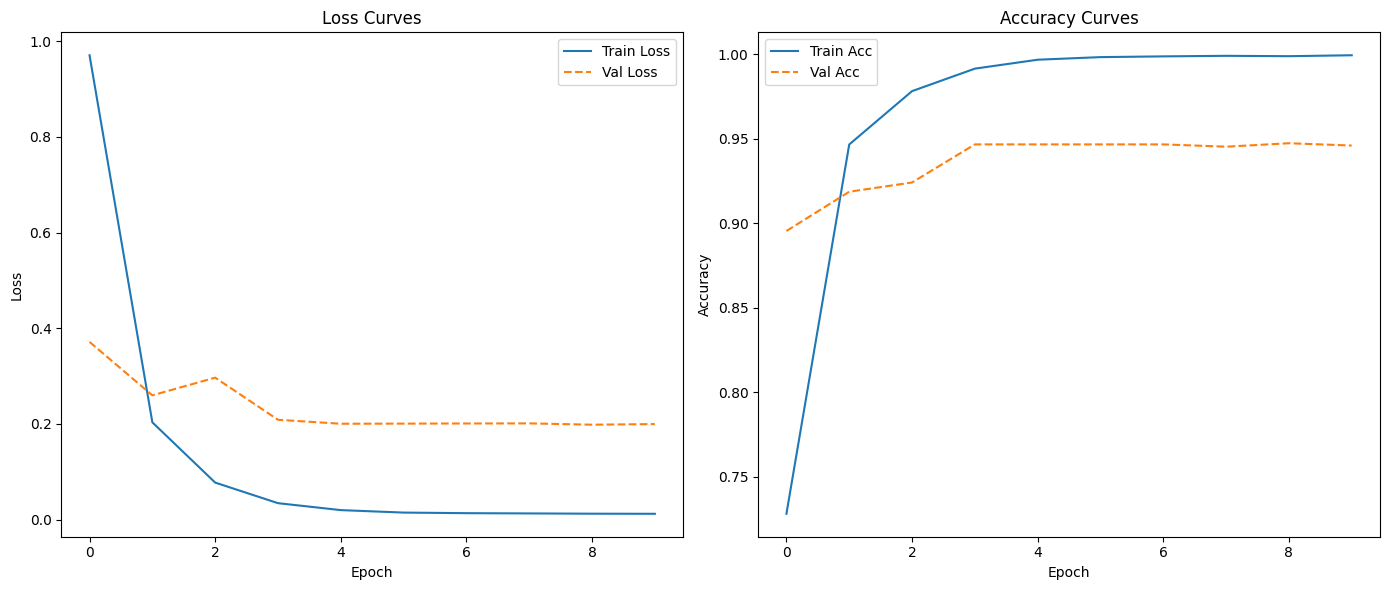

2025-08-13 22:49:35,843 - INFO - wildscan_ml_system.py:402 - train_models() - Model No 2 : AnimalTemporalClassifier_ResNet18 loaded with best weights.
2025-08-13 22:49:35,844 - INFO - wildscan_ml_system.py:407 - evaluate_models() - Evaluating models...
2025-08-13 22:49:35,844 - INFO - wildscan_ml_system.py:413 - evaluate_models() - Found 3 model(s) to evaluate.
2025-08-13 22:49:35,845 - INFO - wildscan_ml_system.py:420 - evaluate_models() - Evaluating Model No 0 : ScratchResNet...
2025-08-13 22:49:35,850 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:49:54,158 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]



=== MODEL ScratchResNet ===
Accuracy: 0.8181691708402894
F1-score (macro): 0.6732969832358419
ROC-AUC: 0.9658381724692343
Classification Report:
               precision    recall  f1-score   support

         car       0.99      1.00      1.00       648
      coyote       0.77      0.83      0.80       526
         dog       0.66      0.77      0.71       299
      bobcat       0.80      0.74      0.77       445
      rabbit       0.83      0.86      0.85      1004
        deer       1.00      0.38      0.56        13
     opossum       0.92      0.89      0.91      2404
     raccoon       0.66      0.85      0.74       507
    squirrel       0.55      0.63      0.58       329
         cat       0.82      0.62      0.71       666
        bird       0.51      0.34      0.41       227
       skunk       0.52      0.81      0.64        58
      rodent       0.75      0.79      0.77        61
         fox       0.00      0.00      0.00         1

    accuracy                           0.

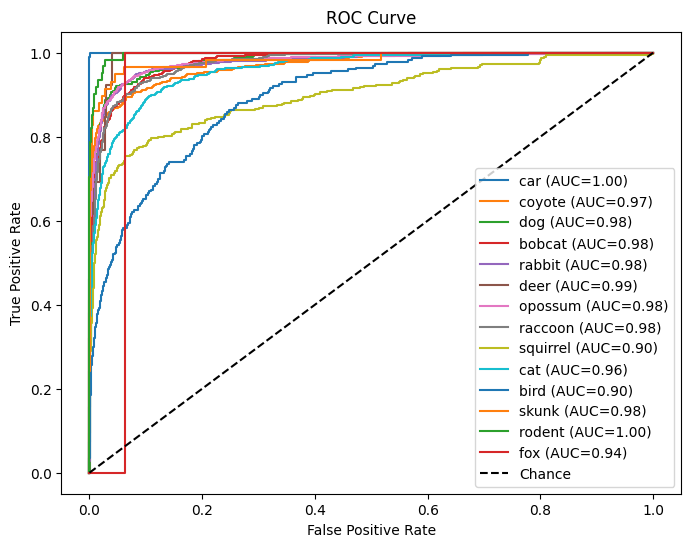

2025-08-13 22:49:54,340 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:50:20,972 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  6  7  8  9 10 11 12]
2025-08-13 22:50:20,974 - WARNING - evaluator.py:99 - evaluate() - Mismatch between present classes in evaluation set and model label mapping. Present classes: [ 0  1  2  3  4  6  7  8  9 10 11 12], Model classes: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])



=== MODEL ScratchResNet ===
Accuracy: 0.6280126065999259
F1-score (macro): 0.4876231859982039
ROC-AUC: not available
Classification Report:
               precision    recall  f1-score   support

         car       1.00      0.99      0.99       747
      coyote       0.44      0.45      0.44      1090
         dog       0.10      0.24      0.14       234
      bobcat       0.73      0.48      0.58      1983
      rabbit       0.57      0.57      0.57       478
        deer       0.00      0.00      0.00         0
     opossum       0.77      0.87      0.82      2438
     raccoon       0.84      0.55      0.66      2647
    squirrel       0.32      0.83      0.47       430
         cat       0.26      0.38      0.31       395
        bird       0.09      0.11      0.10        82
       skunk       0.70      0.69      0.70       249
      rodent       0.04      0.20      0.07        15
         fox       0.00      0.00      0.00         0

    accuracy                           0.63   

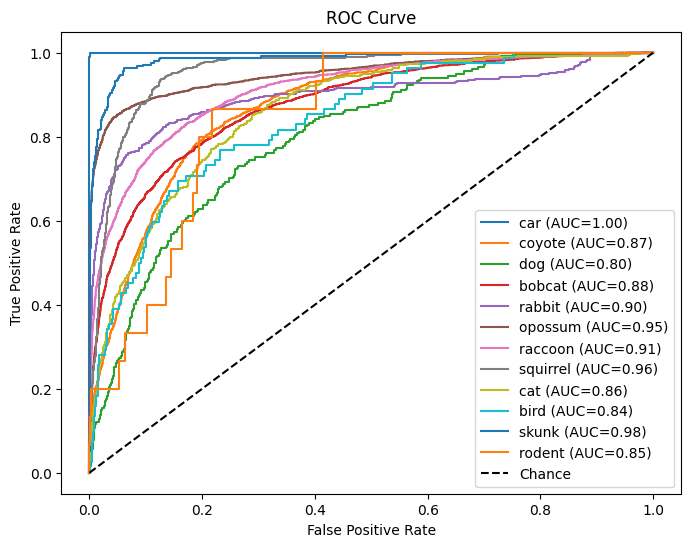

2025-08-13 22:50:21,151 - INFO - wildscan_ml_system.py:420 - evaluate_models() - Evaluating Model No 1 : AnimalClassifier_ResNet18...
2025-08-13 22:50:21,154 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:50:39,191 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]



=== MODEL AnimalClassifier_ResNet18 ===
Accuracy: 0.9067890929326655
F1-score (macro): 0.7891454903875889
ROC-AUC: 0.9918036805950349
Classification Report:
               precision    recall  f1-score   support

         car       1.00      1.00      1.00       648
      coyote       0.84      0.94      0.89       526
         dog       0.79      0.93      0.86       299
      bobcat       0.88      0.91      0.90       445
      rabbit       0.90      0.94      0.92      1004
        deer       0.90      0.69      0.78        13
     opossum       0.97      0.93      0.95      2404
     raccoon       0.87      0.93      0.90       507
    squirrel       0.76      0.79      0.77       329
         cat       0.93      0.86      0.89       666
        bird       0.74      0.44      0.55       227
       skunk       0.78      0.93      0.85        58
      rodent       0.69      0.93      0.79        61
         fox       0.00      0.00      0.00         1

    accuracy                 

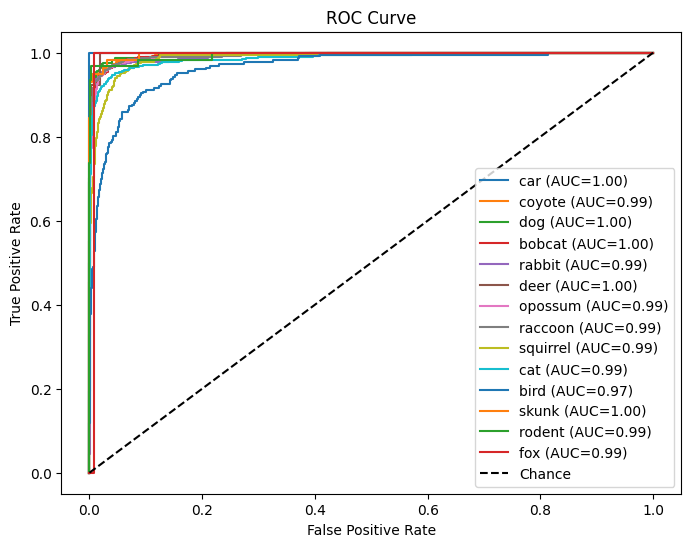

2025-08-13 22:50:39,364 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:51:05,740 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  6  7  8  9 10 11 12]
2025-08-13 22:51:05,741 - WARNING - evaluator.py:99 - evaluate() - Mismatch between present classes in evaluation set and model label mapping. Present classes: [ 0  1  2  3  4  6  7  8  9 10 11 12], Model classes: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])



=== MODEL AnimalClassifier_ResNet18 ===
Accuracy: 0.7915276232851316
F1-score (macro): 0.6215998043124293
ROC-AUC: not available
Classification Report:
               precision    recall  f1-score   support

         car       1.00      1.00      1.00       747
      coyote       0.64      0.82      0.72      1090
         dog       0.28      0.61      0.38       234
      bobcat       0.90      0.74      0.81      1983
      rabbit       0.75      0.85      0.80       478
        deer       0.00      0.00      0.00         0
     opossum       0.90      0.91      0.90      2438
     raccoon       0.94      0.67      0.78      2647
    squirrel       0.56      0.93      0.70       430
         cat       0.45      0.53      0.49       395
        bird       0.44      0.54      0.48        82
       skunk       0.85      0.89      0.87       249
      rodent       0.09      0.33      0.14        15
         fox       0.00      0.00      0.00         0

    accuracy                      

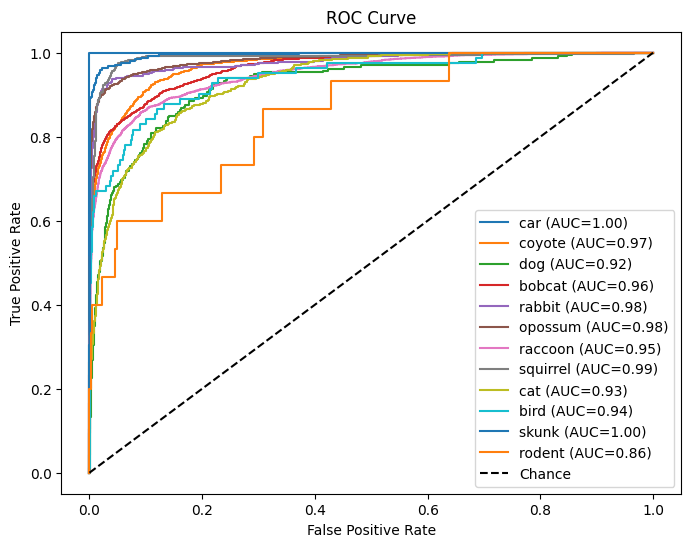

2025-08-13 22:51:05,920 - INFO - wildscan_ml_system.py:420 - evaluate_models() - Evaluating Model No 2 : AnimalTemporalClassifier_ResNet18...
2025-08-13 22:51:05,922 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:51:23,204 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]



=== MODEL AnimalTemporalClassifier_ResNet18 ===
Accuracy: 0.9045631608235949
F1-score (macro): 0.7856521938560773
ROC-AUC: 0.9859054482715844
Classification Report:
               precision    recall  f1-score   support

         car       1.00      1.00      1.00       648
      coyote       0.88      0.93      0.91       526
         dog       0.76      0.94      0.84       299
      bobcat       0.92      0.89      0.91       445
      rabbit       0.91      0.94      0.92      1004
        deer       1.00      0.62      0.76        13
     opossum       0.97      0.92      0.95      2404
     raccoon       0.81      0.96      0.88       507
    squirrel       0.82      0.81      0.82       329
         cat       0.87      0.86      0.86       666
        bird       0.63      0.41      0.50       227
       skunk       0.79      0.93      0.86        58
      rodent       0.73      0.89      0.80        61
         fox       0.00      0.00      0.00         1

    accuracy         

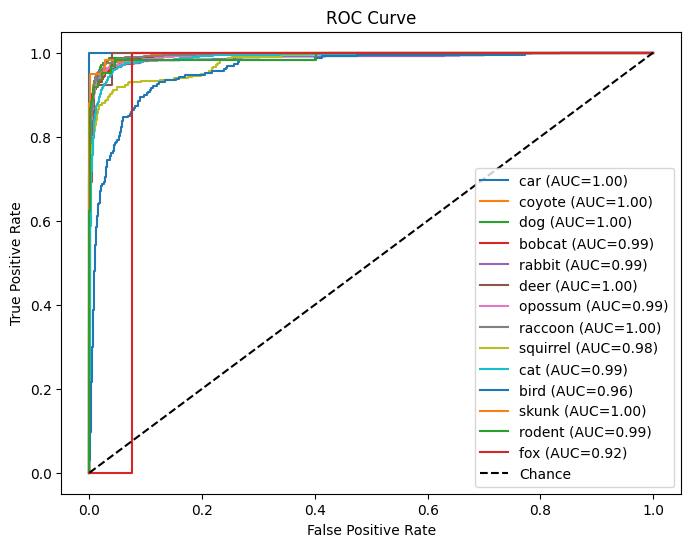

2025-08-13 22:51:23,372 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:51:50,064 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  6  7  8  9 10 11 12]
2025-08-13 22:51:50,065 - WARNING - evaluator.py:99 - evaluate() - Mismatch between present classes in evaluation set and model label mapping. Present classes: [ 0  1  2  3  4  6  7  8  9 10 11 12], Model classes: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])



=== MODEL AnimalTemporalClassifier_ResNet18 ===
Accuracy: 0.7875417130144605
F1-score (macro): 0.6144230234316972
ROC-AUC: not available
Classification Report:
               precision    recall  f1-score   support

         car       1.00      1.00      1.00       747
      coyote       0.64      0.81      0.72      1090
         dog       0.24      0.60      0.34       234
      bobcat       0.95      0.71      0.81      1983
      rabbit       0.80      0.81      0.81       478
        deer       0.00      0.00      0.00         0
     opossum       0.92      0.90      0.91      2438
     raccoon       0.91      0.70      0.79      2647
    squirrel       0.59      0.91      0.71       430
         cat       0.38      0.56      0.45       395
        bird       0.43      0.51      0.47        82
       skunk       0.80      0.89      0.84       249
      rodent       0.08      0.33      0.13        15
         fox       0.00      0.00      0.00         0

    accuracy              

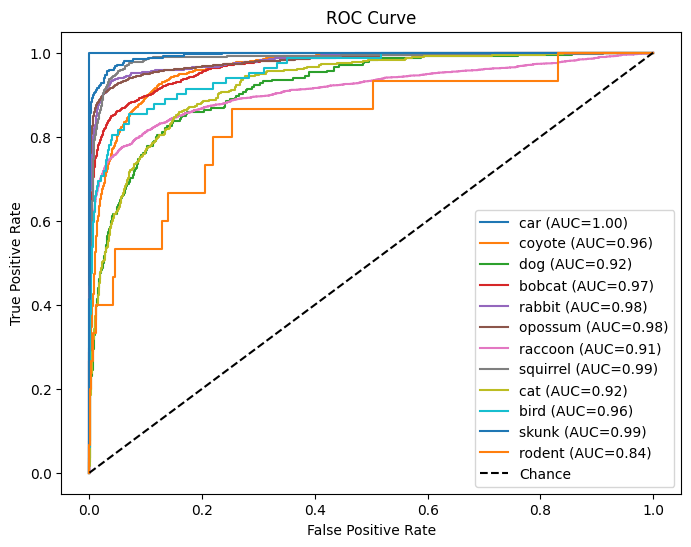

2025-08-13 22:51:50,230 - INFO - wildscan_ml_system.py:448 - evaluate_confidences() - Evaluating Confidence Metrics for Model No 0 : ScratchResNet...
2025-08-13 22:51:50,230 - INFO - wildscan_ml_system.py:449 - evaluate_confidences() - Setup calibration data from validation set for this model...
2025-08-13 22:51:50,232 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:51:53,945 - INFO - wildscan_ml_system.py:471 - evaluate_confidences() - Calibration complete for Model No 0 : ScratchResNet
2025-08-13 22:51:53,945 - INFO - wildscan_ml_system.py:473 - evaluate_confidences() - Evaluating confidence metrics on in-distribution test set...
2025-08-13 22:51:53,947 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps


Dataset  7188 test samples, 14 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.032685,0.022794,30.263045
1,Overconfidence Error,0.032281,0.006973,0.000000
2,Brier Score,0.107914,0.108060,0.000000


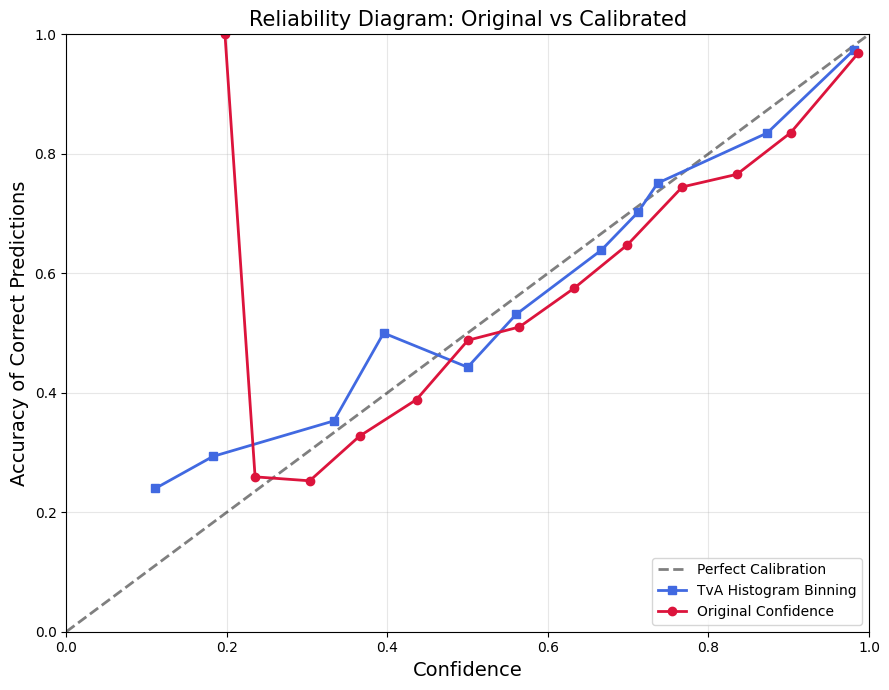

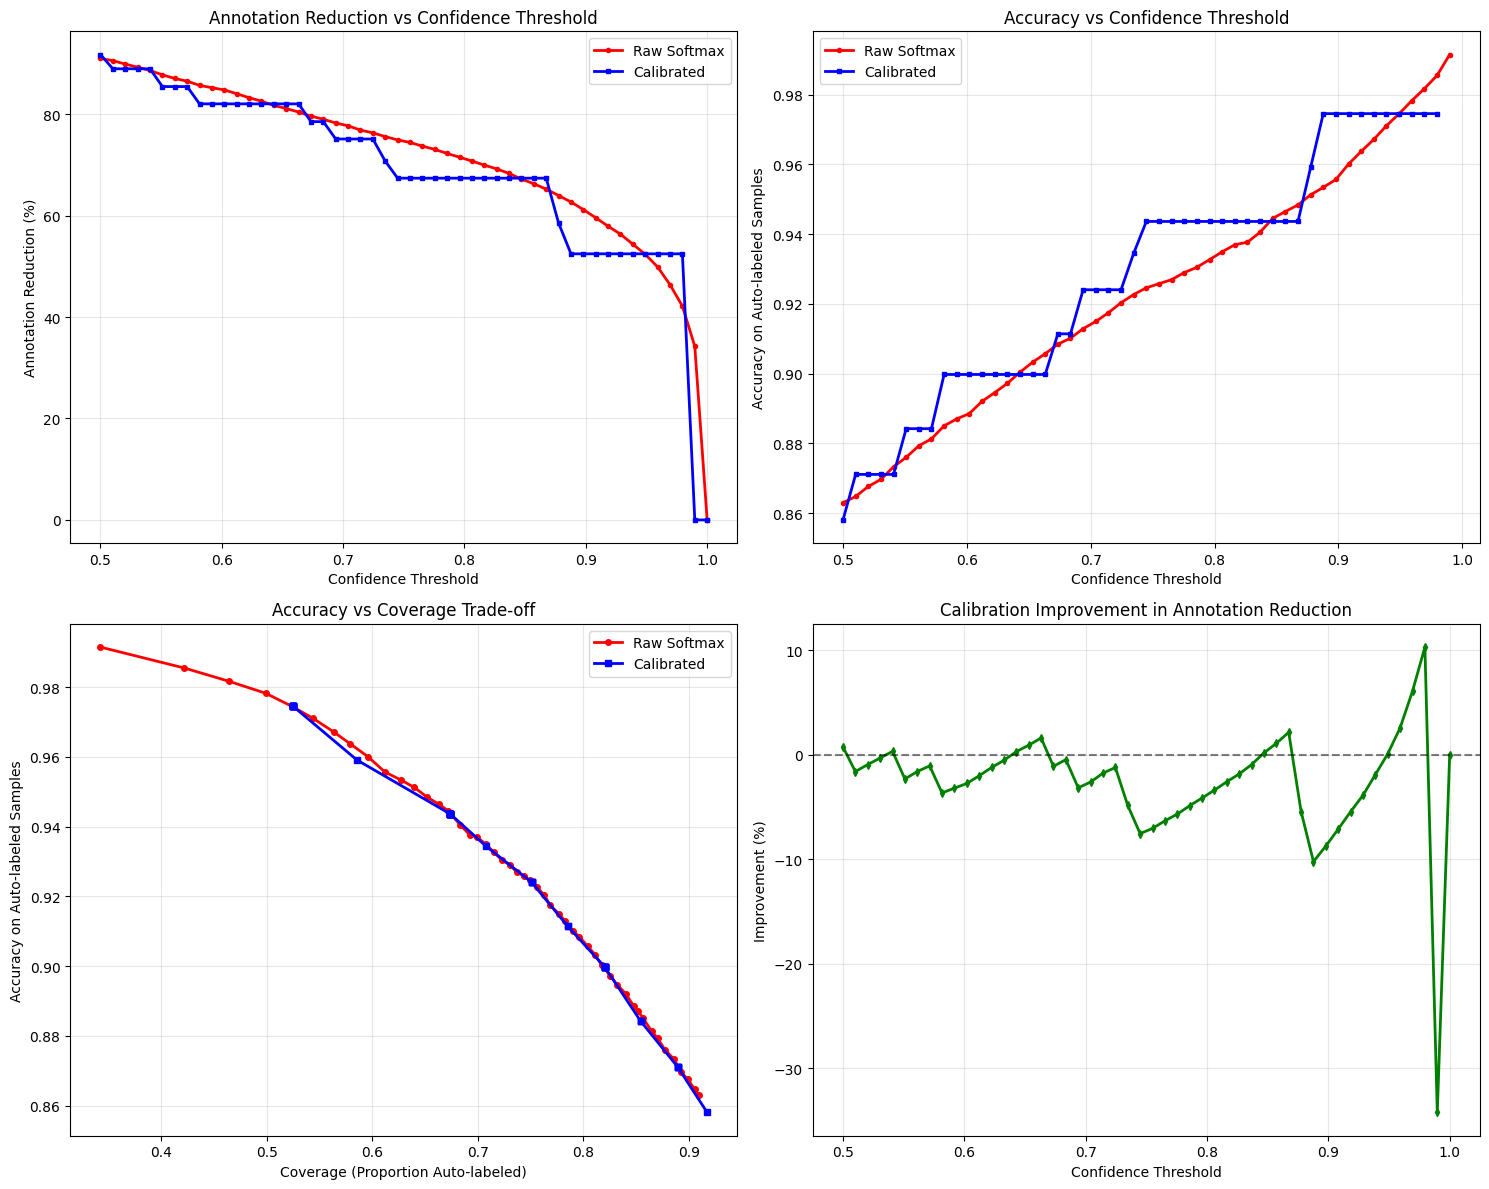

2025-08-13 22:52:13,020 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:52:39,810 - INFO - wildscan_ml_system.py:503 - evaluate_confidences() - Evaluating confidence metrics on out-of-distribution test set...


Dataset  10788 test samples, 12 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.156084,0.131067,16.027448
1,Overconfidence Error,0.155818,0.124347,0.000000
2,Brier Score,0.200966,0.194886,0.000000


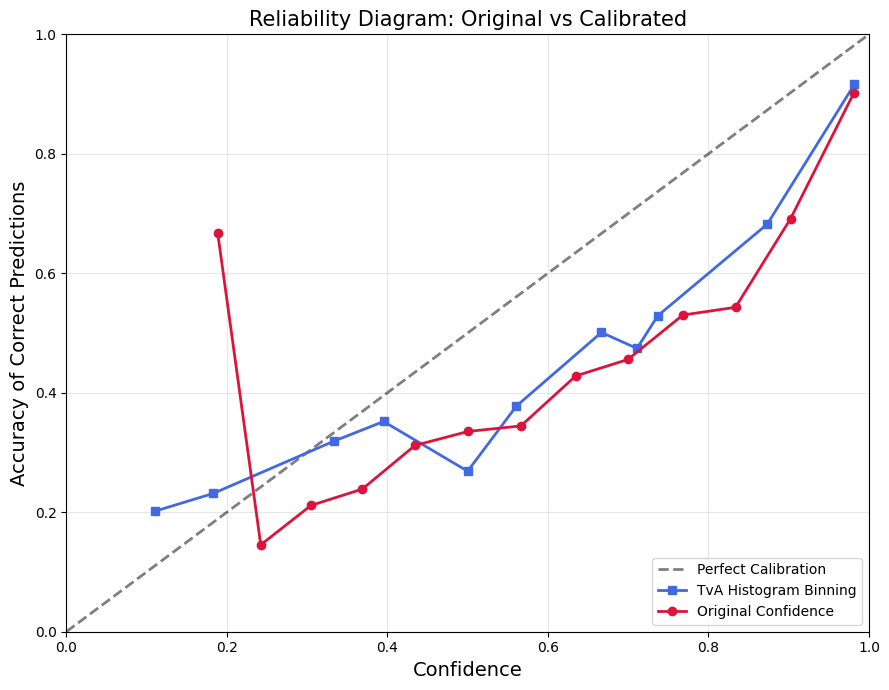

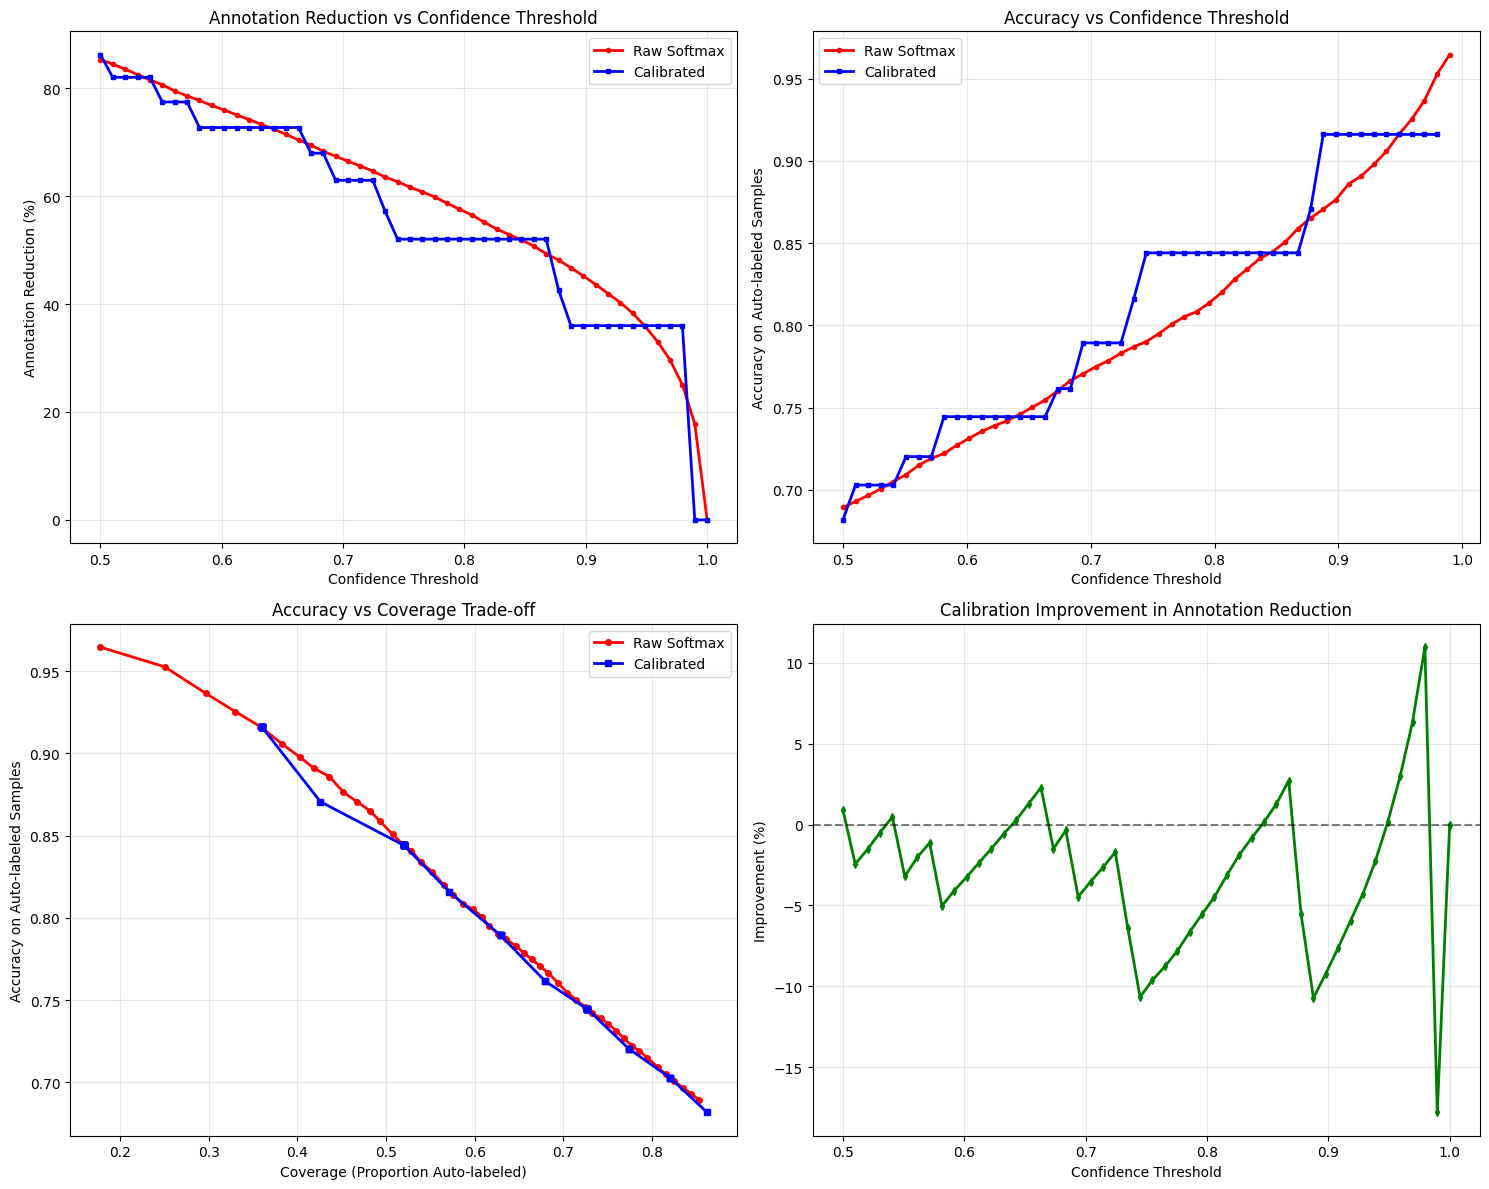

2025-08-13 22:52:40,199 - INFO - wildscan_ml_system.py:448 - evaluate_confidences() - Evaluating Confidence Metrics for Model No 1 : AnimalClassifier_ResNet18...
2025-08-13 22:52:40,199 - INFO - wildscan_ml_system.py:449 - evaluate_confidences() - Setup calibration data from validation set for this model...
2025-08-13 22:52:40,202 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:52:43,934 - INFO - wildscan_ml_system.py:471 - evaluate_confidences() - Calibration complete for Model No 1 : AnimalClassifier_ResNet18
2025-08-13 22:52:43,935 - INFO - wildscan_ml_system.py:473 - evaluate_confidences() - Evaluating confidence metrics on in-distribution test set...
2025-08-13 22:52:43,937 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps


Dataset  7188 test samples, 14 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.023126,0.025647,-10.900963
1,Overconfidence Error,0.023126,-0.007752,0.000000
2,Brier Score,0.058021,0.061209,0.000000


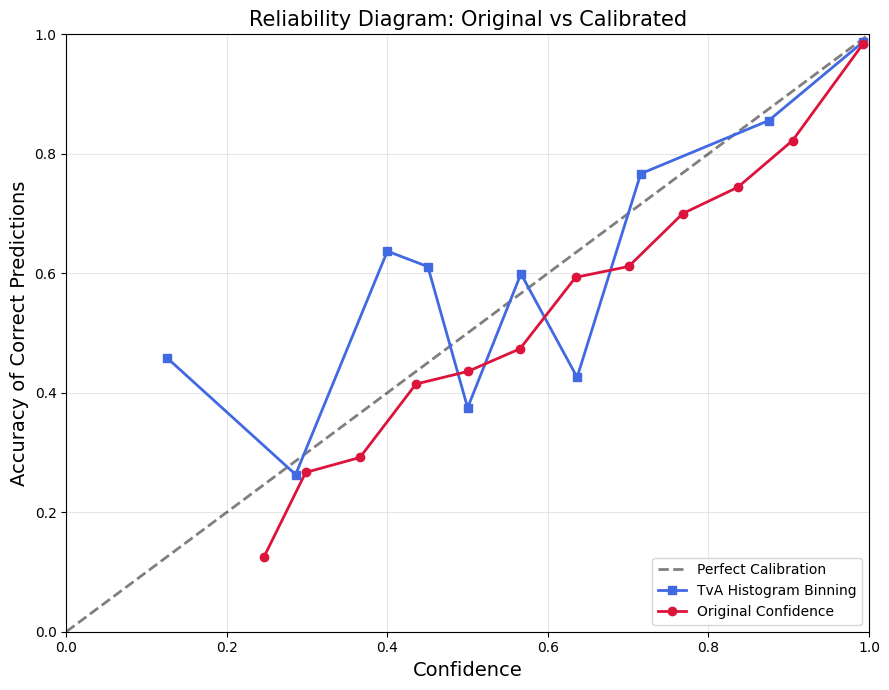

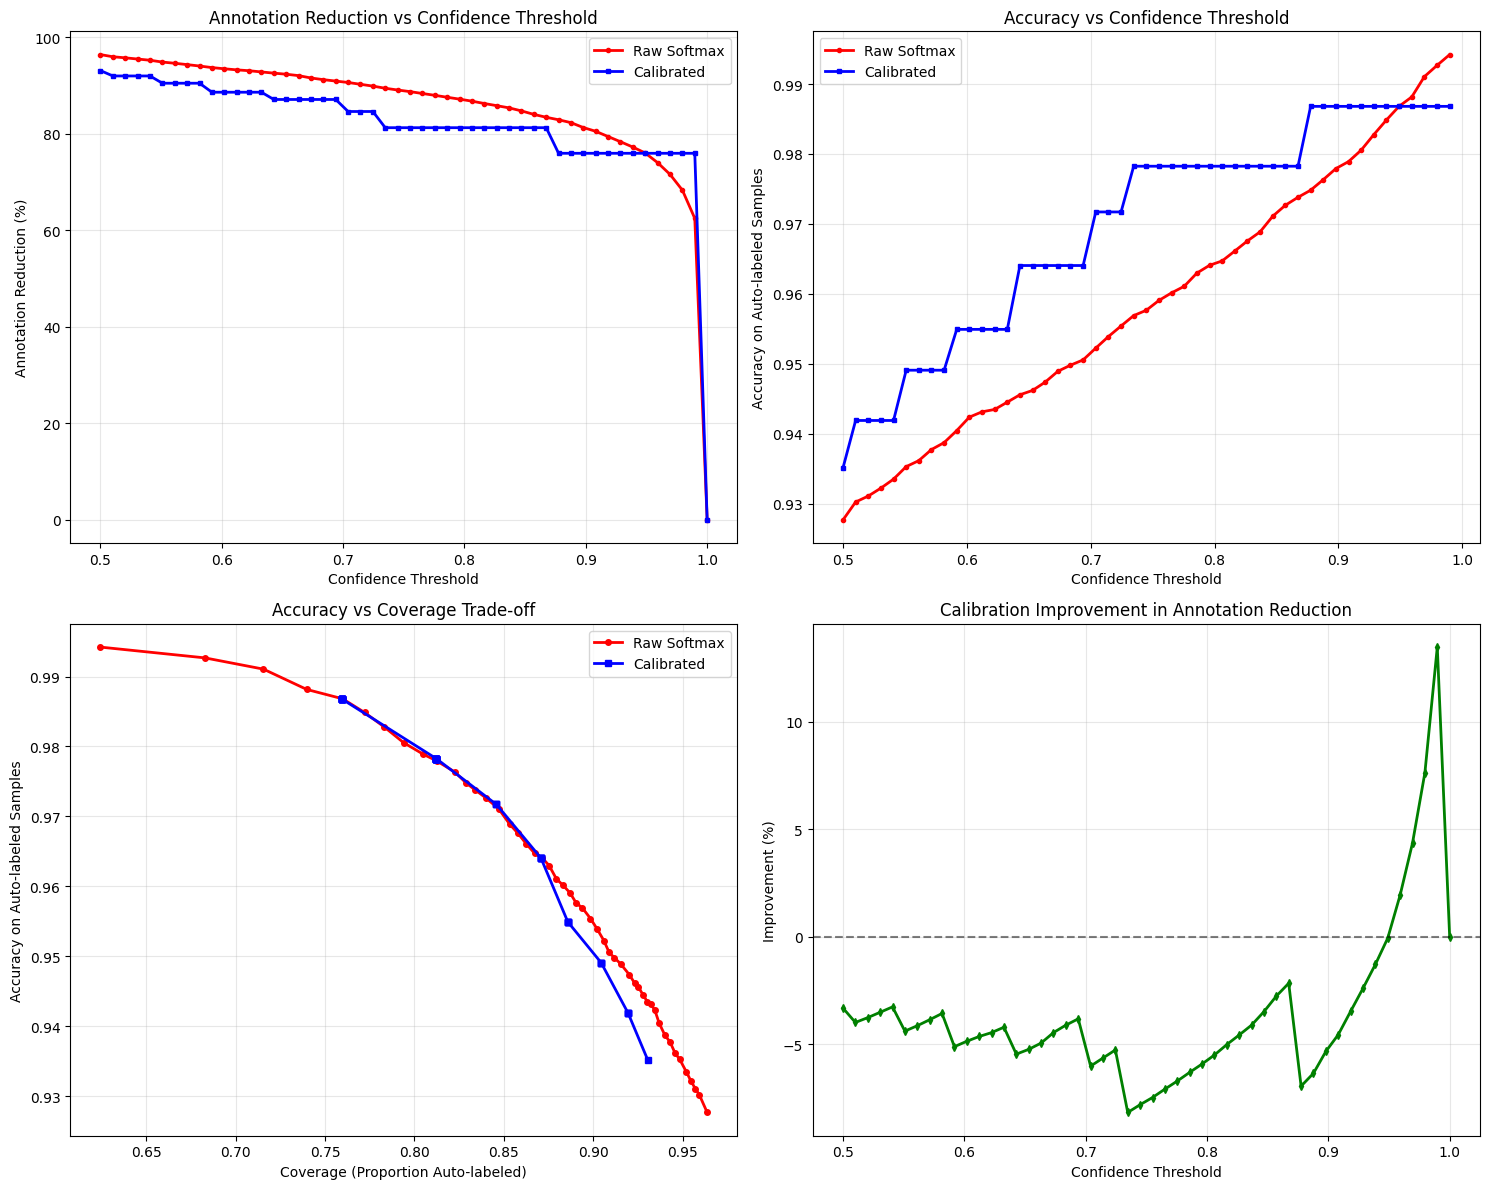

2025-08-13 22:53:02,032 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:53:28,231 - INFO - wildscan_ml_system.py:503 - evaluate_confidences() - Evaluating confidence metrics on out-of-distribution test set...


Dataset  10788 test samples, 12 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.087237,0.054248,37.815786
1,Overconfidence Error,0.087233,0.039996,0.000000
2,Brier Score,0.121297,0.116075,0.000000


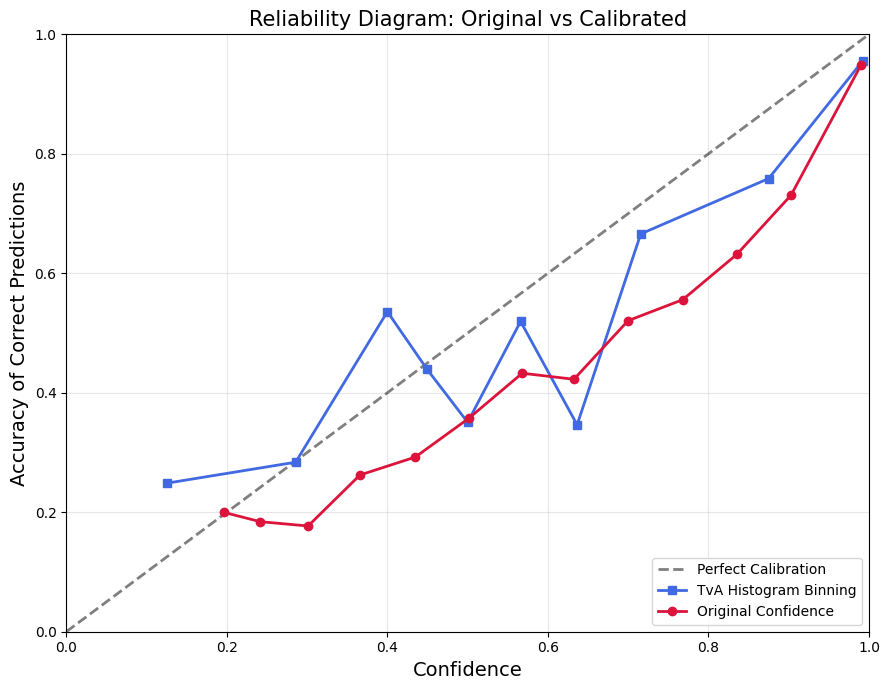

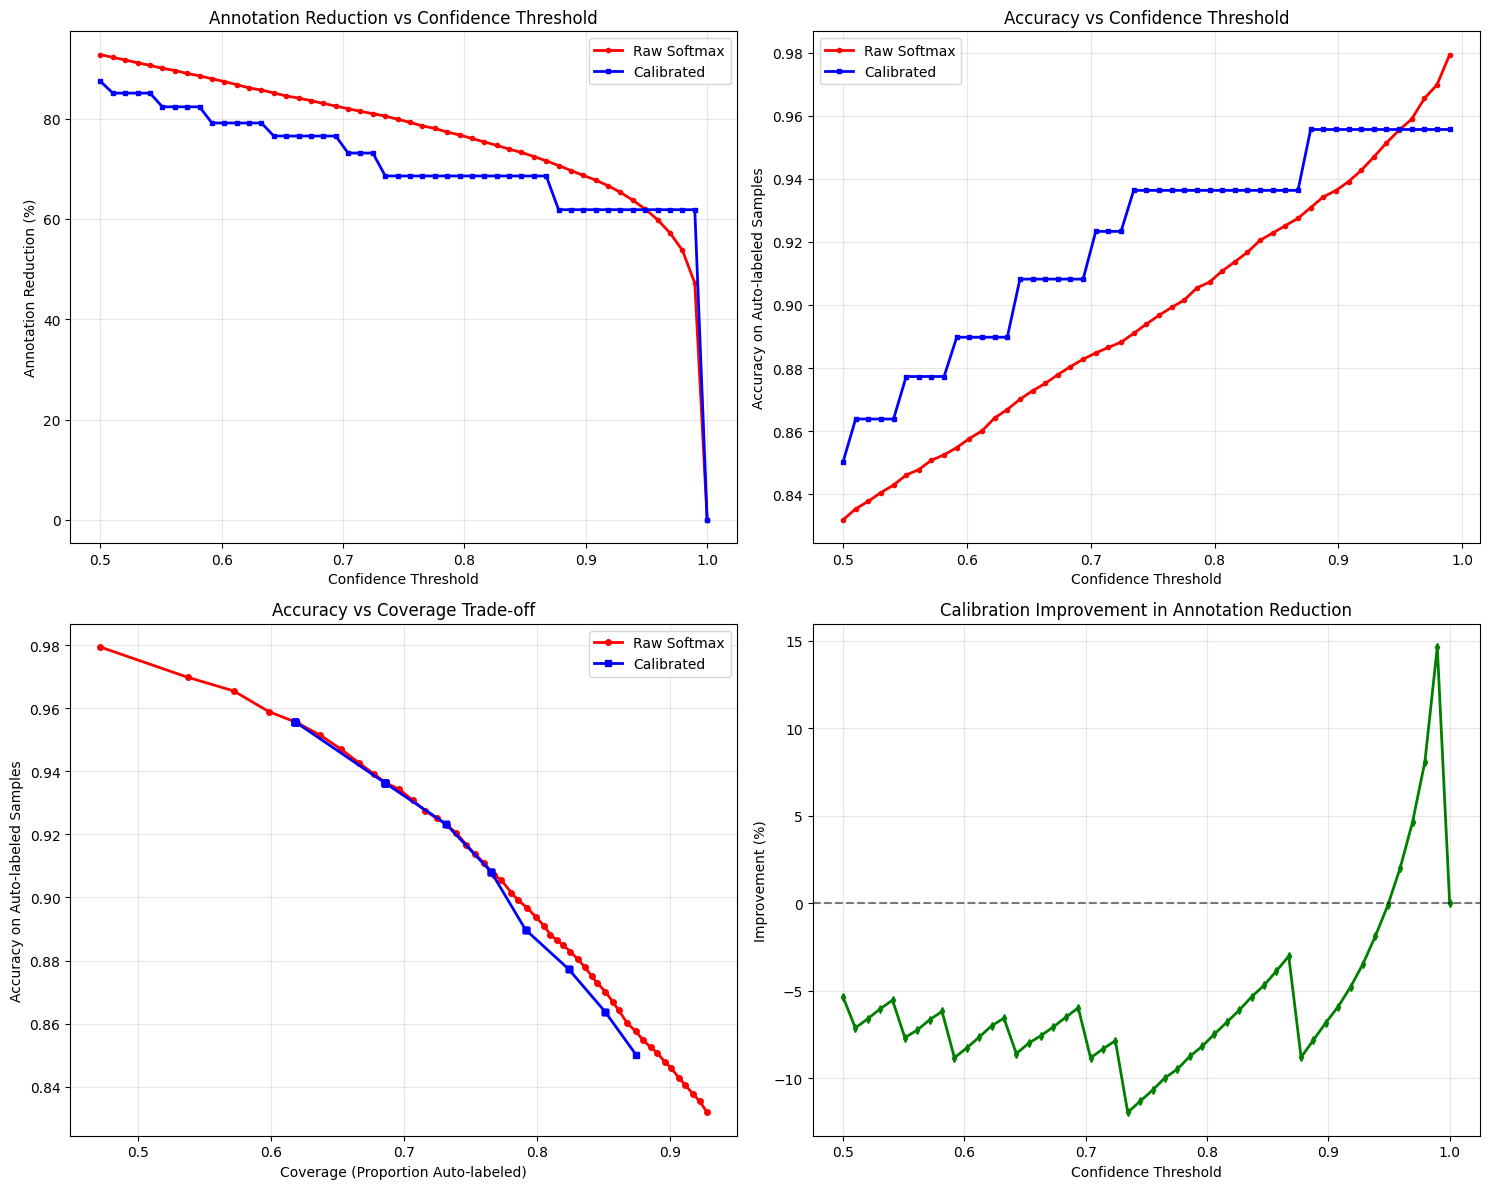

2025-08-13 22:53:28,684 - INFO - wildscan_ml_system.py:448 - evaluate_confidences() - Evaluating Confidence Metrics for Model No 2 : AnimalTemporalClassifier_ResNet18...
2025-08-13 22:53:28,684 - INFO - wildscan_ml_system.py:449 - evaluate_confidences() - Setup calibration data from validation set for this model...
2025-08-13 22:53:28,686 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:53:32,415 - INFO - wildscan_ml_system.py:471 - evaluate_confidences() - Calibration complete for Model No 2 : AnimalTemporalClassifier_ResNet18
2025-08-13 22:53:32,416 - INFO - wildscan_ml_system.py:473 - evaluate_confidences() - Evaluating confidence metrics on in-distribution test set...
2025-08-13 22:53:32,417 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps


Dataset  7188 test samples, 14 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.022447,0.028292,-26.039358
1,Overconfidence Error,0.022168,-0.001990,0.000000
2,Brier Score,0.061323,0.064187,0.000000


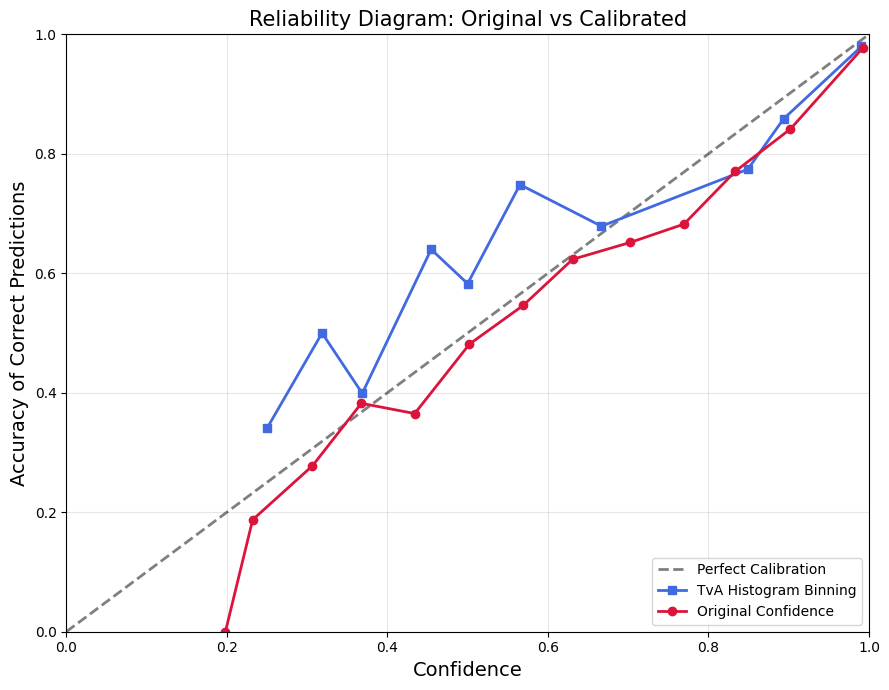

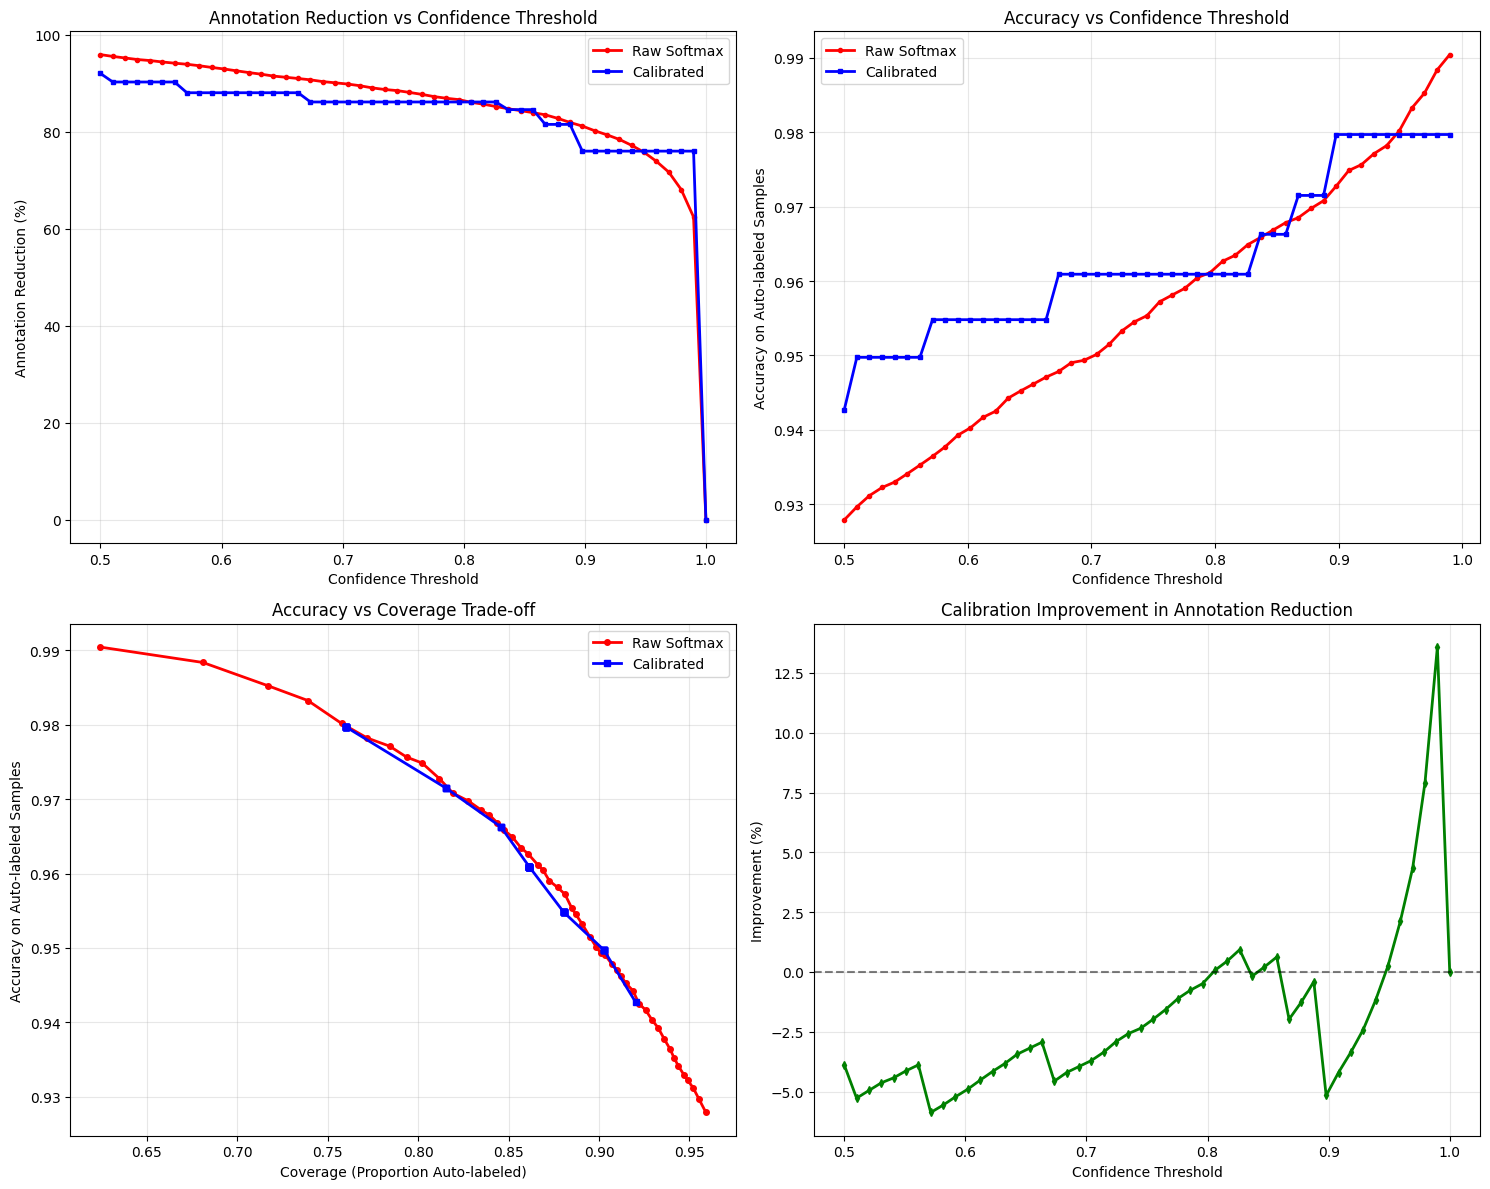

2025-08-13 22:53:50,522 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-13 22:54:15,855 - INFO - wildscan_ml_system.py:503 - evaluate_confidences() - Evaluating confidence metrics on out-of-distribution test set...


Dataset  10788 test samples, 12 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.100094,0.075230,24.8402
1,Overconfidence Error,0.099877,0.065647,0.0000
2,Brier Score,0.130666,0.127248,0.0000


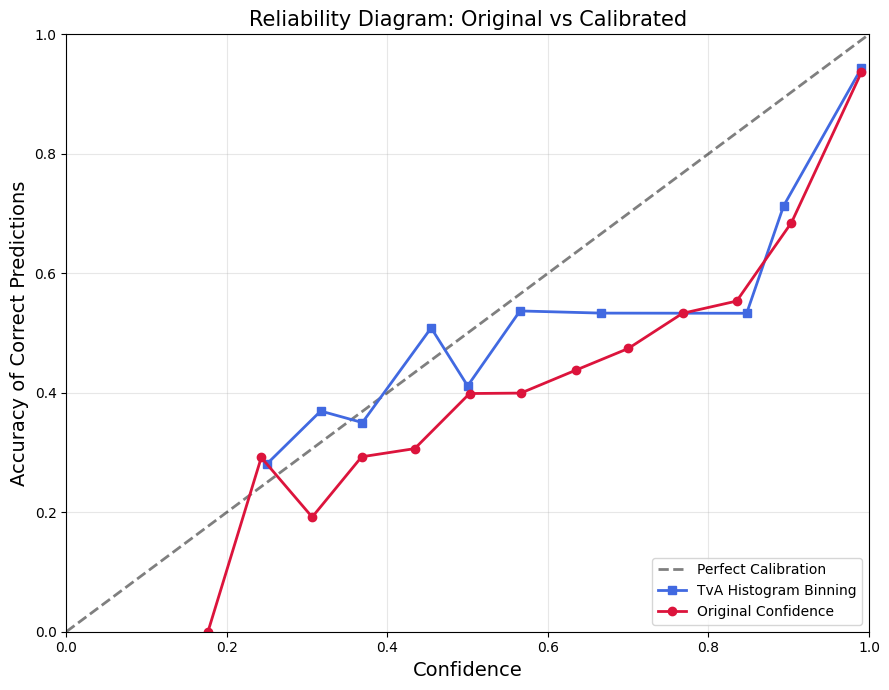

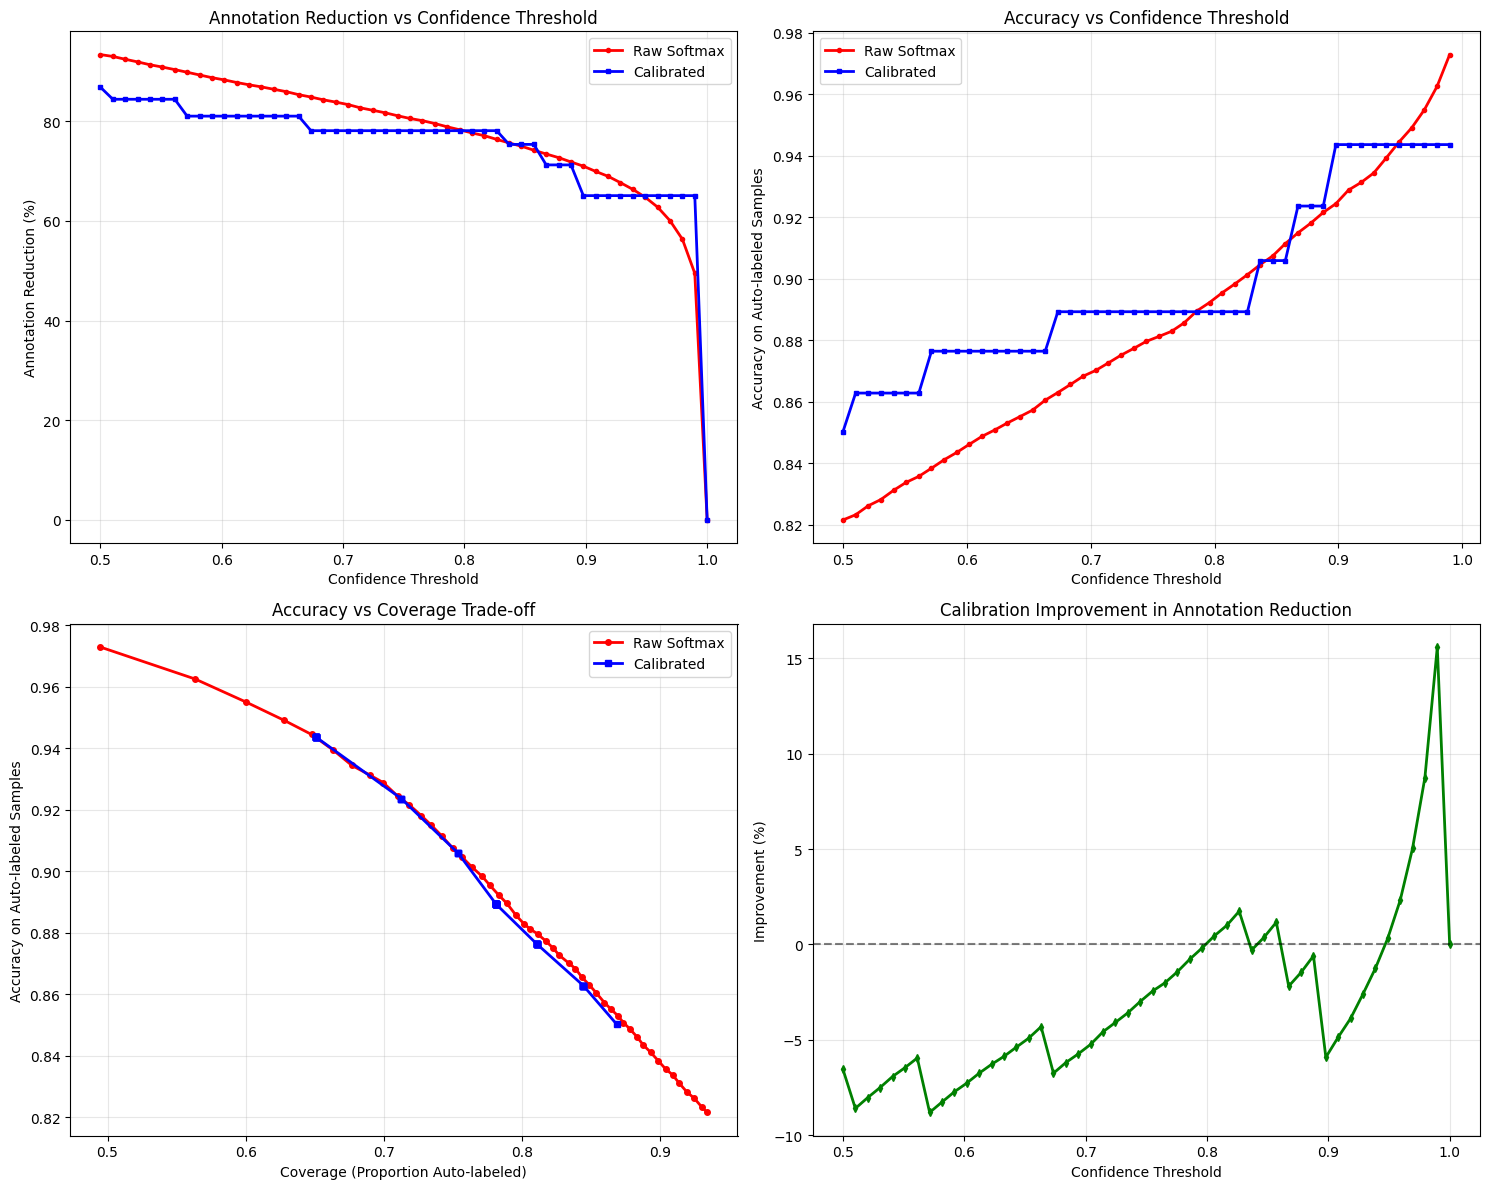

{'models': {0: ScratchResNet(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (layer1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [5]:
# Step 5: Run PretrainingPipeline Directly
pretraining_pipeline.run_pipeline()

---
### Section 2. Observations and Analysis
        * Overfitting observed on both Models 1 & 2 although the loss is quite low at around 0.20
        * Very similar classification performance between Model 1 and Model 2.
        * At least for the 1st year data, the added temporal vector feature of Model 2 offered no significant improvement
        * all models are well calibrated on the in-location test set (original confidence reliability plots are close to y=x)
        * all models are over confident in their predictions on the out-location set, specially at high confidence levels
        * the Reliability diagrams and resuling calibration metrics on this final notebook re-run are different from the ones in our report. We still see similar scores between Models 1 and 2, but over all Model 1 outperforms Model 2 on this run. suggesting possible reproducibility issue somewhere in our code.  

---
### Section 3. Future Work (Once Production Pipeline is Ready, it would be easier to try the following)

    1. Address the overfitting on the Resnet18 variants: l1/l2 regularization, modify architecture of hidden layers prior to fc. image augmentation, add Dropout, etc
    2. Try other architectures and fusion techniques on merging temporal vector with a large-model architecture.
    3. Explore time-split-cross-validation so we dont have to split the newly annotated uncertain samples into train-val. 
    4. Try other calibration methods with TvA. 
    5. Investigate the effect of n_bins when using TvA Histogram Binning,